In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from pygments import style
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import kagglehub as kgh


In [19]:
path = kgh.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

csv_path = os.path.join(path , "WA_Fn-UseC_-Telco-Customer-Churn.csv")

Path to dataset files: C:\Users\Legion5\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [20]:
df  = pd.read_csv(csv_path)
print(df.shape)

(7043, 21)


In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df.duplicated().sum()


np.int64(0)

In [25]:
df = df.drop_duplicates()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" " , np.nan))
df["Churn"] = df["Churn"].map(
    {
        "Yes": 1,
        "No" : 0
    }
)

X = df.drop(columns=['customerID' , 'Churn'])
y = df['Churn']

X_train , X_test , y_train , y_test = train_test_split(
    X,y, test_size=0.20,random_state=42,stratify=y
)


In [27]:

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]



In [28]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , roc_auc_score

num_pipline = Pipeline([
    ('imputer' , SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])

cat_pipline = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('ohe' ,  OneHotEncoder(handle_unknown='ignore' , sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num" , num_pipline , num_cols),
        ("cat" , cat_pipline , cat_cols)
    ],
    remainder='drop'
)

fullPipeline = Pipeline([
    ('preprocess' , preprocess),
    ('classifier' , LogisticRegression(class_weight="balanced" , random_state=42,max_iter=1_000))
])


In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


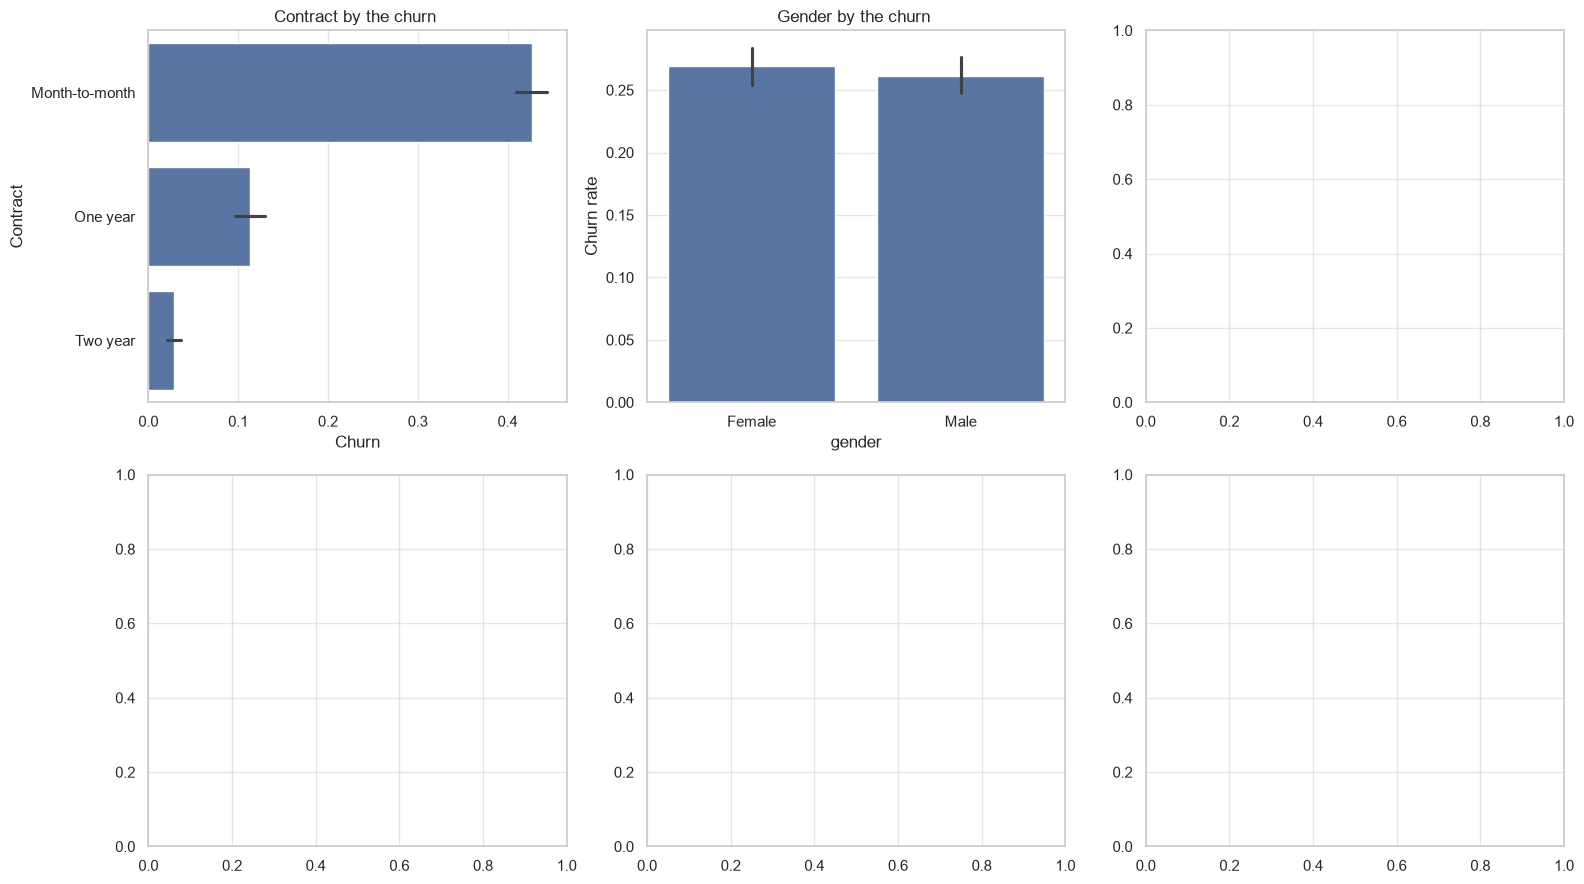

In [30]:
sns.set_theme(style='whitegrid')
fig , ax = plt.subplots(2,3,figsize=(16,9))
axes = ax.flatten()

sns.barplot(
    x='Churn',
    y='Contract',
    data=df,
    estimator='mean',
    ax=axes[0]
)
axes[0].set_title("Contract by the churn ")

sns.barplot(
    x='gender',
    y='Churn',
    data=df,
    estimator='mean',
    ax=axes[1]
)
axes[1].set_title("Gender by the churn ")
axes[1].set_ylabel("Churn rate")

plt.tight_layout()
plt.show()

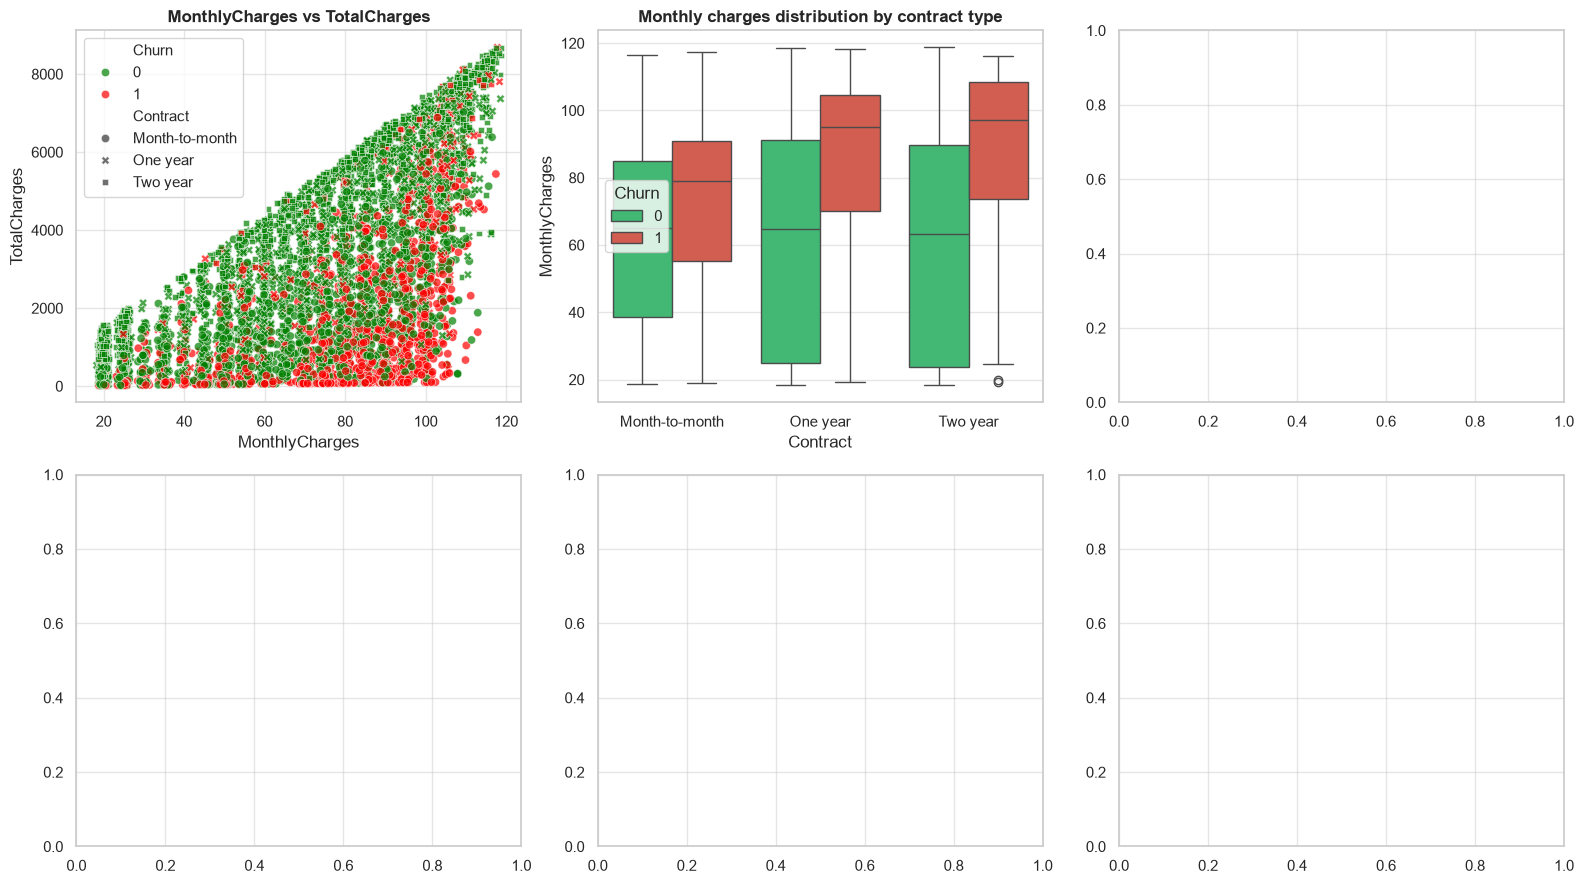

In [31]:
sns.set_theme(style="whitegrid")
fig , ax = plt.subplots(2,3,figsize=(16,9))
axes = ax.flatten()

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn",
    style="Contract",
    alpha=0.7,
    palette={1: 'red', 0: 'green'},
    ax=axes[0]
)
axes[0].set_title("MonthlyCharges vs TotalCharges" , fontsize=12,fontweight='bold')

sns.boxplot(
    data=df,
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    palette={1: '#e74c3c', 0: '#2ecc71'},
    ax=axes[1],
)
axes[1].set_title("Monthly charges distribution by contract type" , fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()


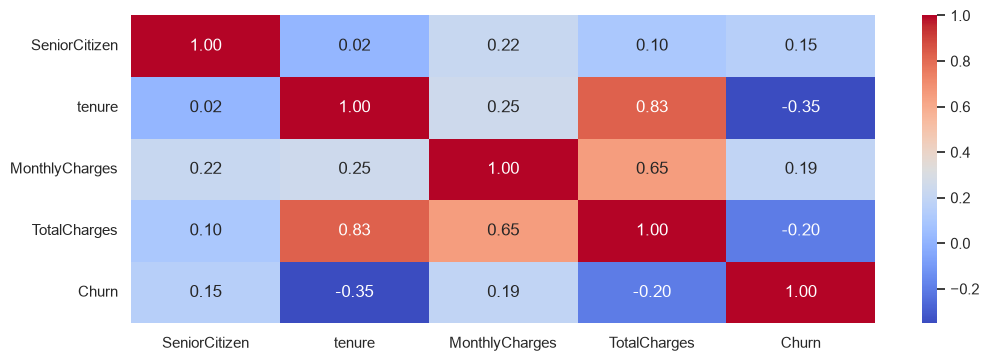

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,4))
sns.heatmap(corr,annot=True , cmap='coolwarm',fmt='.2f')
plt.show()


In [33]:
#print(f"X_train shape : {X_train.shape}")
#print(f"X_test shape : {X_test.shape}")
#print(f"y_train shape : {y_train.shape}")
#print(f"y_test shape : {y_test.shape}")

print(f"X train shape : {X_train.shape}")
print(f"X test shape : {X_test.shape}")
print(f"y train shape : {y_train.shape}")
print(f"y test shape : {y_test.shape}")


X train shape : (5634, 19)
X test shape : (1409, 19)
y train shape : (5634,)
y test shape : (1409,)


In [37]:
fullPipeline.fit(X_train , y_train)

y_pred = fullPipeline.predict(X_test)
y_proba = fullPipeline.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test , y_proba)

print(f"ROC auc score : {roc_score * 100}% ")
print(classification_report(y_test , y_pred))


ROC auc score : 84.14063912785139% 
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

